In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("../data/PJME_hourly.csv")
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [15]:
df.shape

(145366, 2)

In [16]:
df.columns

Index(['Datetime', 'PJME_MW'], dtype='str')

In [17]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')
df = df.set_index('Datetime')

In [18]:
df.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [19]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 145366 entries, 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PJME_MW  145366 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB


In [ ]:
df.isnull().sum()

PJME_MW    0
dtype: int64

In [22]:
df.index.duplicated().sum()

np.int64(4)

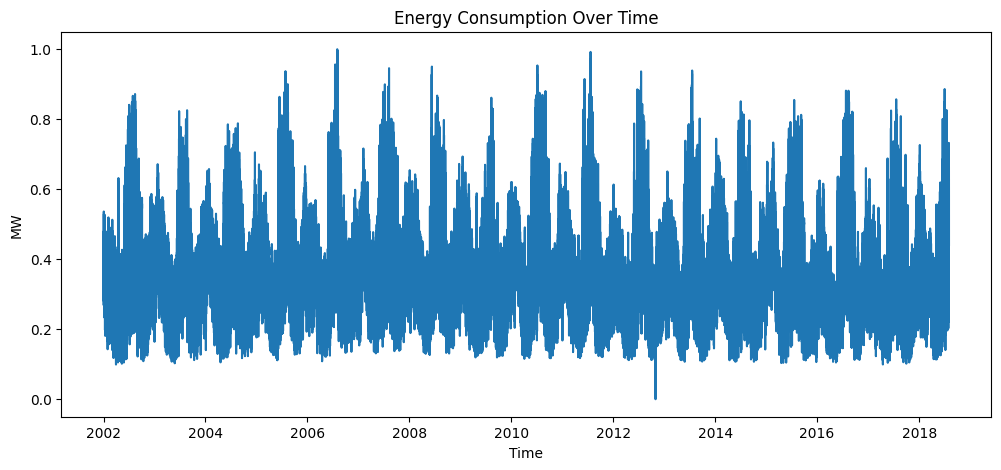

<Figure size 640x480 with 0 Axes>

In [82]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df.iloc[:,0])
plt.title("Energy Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("MW")
plt.show()
plt.savefig("../figures/EnergyConsumptionOverTime.png")

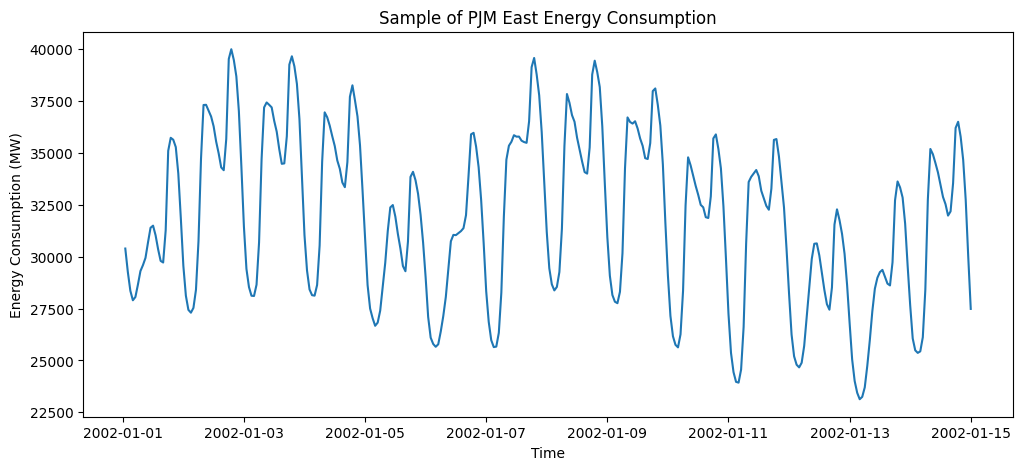

In [23]:
sample = df.iloc[:24*14]
plt.figure(figsize=(12, 5))
plt.plot(sample.index, sample['PJME_MW'])
plt.title('Sample of PJM East Energy Consumption')
plt.xlabel('Time')
plt.ylabel('Energy Consumption (MW)')
plt.show()

In [28]:
df = df[~df.index.duplicated(keep='first')]

In [29]:
df[df.index.duplicated()]

,PJME_MW
Datetime,


In [ ]:
#Checking for Missing hours
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
missing_timestamps = full_range.difference(df.index)

len(missing_timestamps)

30

Including all hours 

In [33]:
df = df.reindex(full_range)

In [34]:
df.isnull().sum()

PJME_MW    30
dtype: int64

Filling missing values using Interpolation


In [35]:
df['PJME_MW'] = df['PJME_MW'].interpolate(method='linear')

In [36]:
df.isnull().sum()

PJME_MW    0
dtype: int64

Normalization 


In [37]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['PJME_MW'] = scaler.fit_transform(df[['PJME_MW']])

In [38]:
df.head()

,PJME_MW
2002-01-01 01:00:00,0.333909
2002-01-01 02:00:00,0.310144
2002-01-01 03:00:00,0.291014
2002-01-01 04:00:00,0.281365
2002-01-01 05:00:00,0.284694


Sliding Windows

In [45]:
data = df['PJME_MW'].values

In [52]:
input_window = 168
output_window = 24

In [53]:
print(input_window, output_window)

168 24


In [54]:
X = []
y = []

In [55]:
for i in range(len(data) - input_window - output_window):
    X.append(data[i : i + input_window])
    y.append(data[i + input_window : i + input_window + output_window])

X = np.array(X)
y = np.array(y)

In [57]:
print(X.shape)
print(y.shape)

(145200, 168)
(145200, 24)


In [58]:
print(X[0].shape)
print(y[0].shape)

(168,)
(24,)


In [60]:
print(X.shape)
print(y.shape)
print(X[0].shape)
print(y[0].shape)

(145200, 168)
(145200, 24)
(168,)
(24,)


Splitting into Train,Validation,Test
70% train
15% validation
15% test


In [61]:
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)
test_size = len(X) - train_size - val_size

print(train_size, val_size, test_size)

101640 21780 21780


In [62]:
X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

In [63]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(101640, 168) (101640, 24)
(21780, 168) (21780, 24)
(21780, 168) (21780, 24)


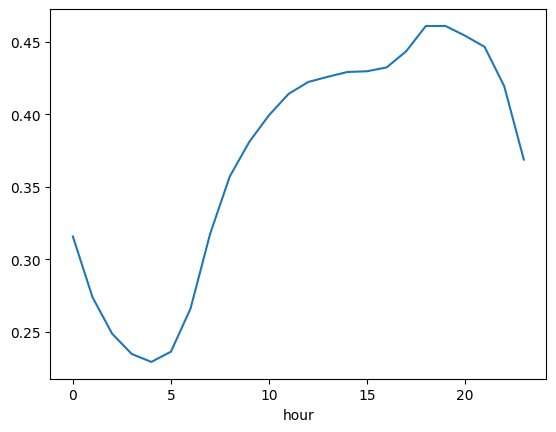

In [65]:
df['hour'] = df.index.hour
df.groupby('hour')['PJME_MW'].mean().plot()
plt.savefig("../figures/daily_pattern.png")

LSTM Baseline 


In [67]:
X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val_lstm = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test_lstm = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [68]:
print(X_train_lstm.shape)
print(X_val_lstm.shape)
print(X_test_lstm.shape)

(101640, 168, 1)
(21780, 168, 1)
(21780, 168, 1)


In [70]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [71]:
model = Sequential([
    LSTM(32, input_shape=(168, 1)),
    Dense(24)
])

/Users/yajatwork/DL-energy-forecast/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [72]:
model.compile(optimizer='adam', loss='mse')

In [73]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,144 (20.09 KB)

 Trainable params: 5,144 (20.09 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [76]:
history = model.fit(
    X_train_lstm,
    y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
1589/1589 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - loss: 0.0021 - val_loss: 0.0024
Epoch 2/20
1589/1589 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 3/20
1589/1589 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - loss: 0.0018 - val_loss: 0.0022
Epoch 4/20
1589/1589 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - loss: 0.0018 - val_loss: 0.0018
Epoch 5/20
1589/1589 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - loss: 0.0017 - val_loss: 0.0018
Epoch 6/20
1589/1589 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - loss: 0.0017 - val_loss: 0.0019


In [77]:
test_loss = model.evaluate(X_test_lstm, y_test, verbose=1)
print("Test MSE:", test_loss)

681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0022
Test MSE: 0.0021634732838720083


In [78]:
import os
os.makedirs("../figures", exist_ok=True)

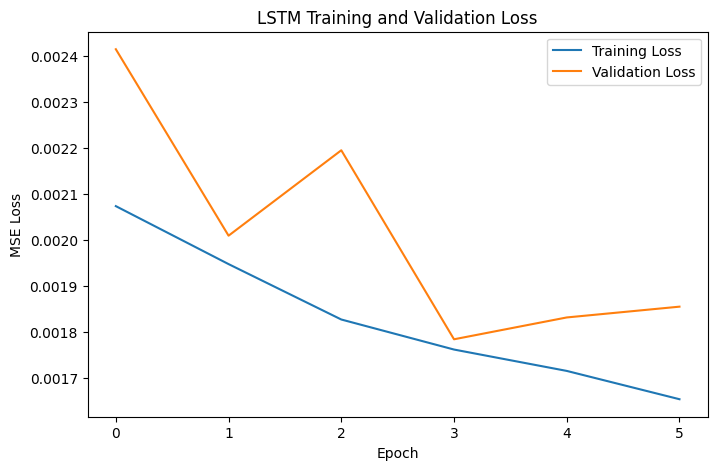

In [79]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()

plt.savefig("../figures/lstm_loss_curve.png", dpi=300, bbox_inches='tight')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


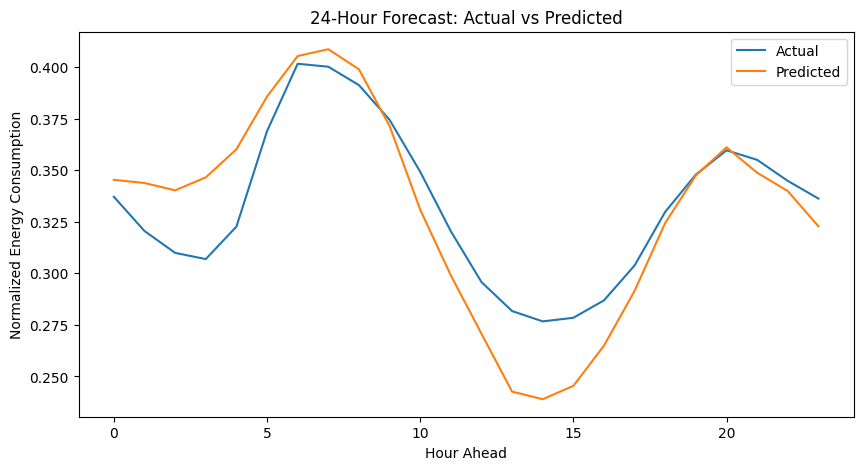

In [80]:
y_pred = model.predict(X_test_lstm[:1])

plt.figure(figsize=(10,5))
plt.plot(y_test[0], label='Actual')
plt.plot(y_pred[0], label='Predicted')
plt.title('24-Hour Forecast: Actual vs Predicted')
plt.xlabel('Hour Ahead')
plt.ylabel('Normalized Energy Consumption')
plt.legend()

plt.savefig("../figures/lstm_forecast_example.png", dpi=300, bbox_inches='tight')
plt.show()